In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import sys, platform, os
import matplotlib
from matplotlib import pyplot as plt
import numpy as np
import camb
from camb import model, initialpower
import scipy.constants as C
import scipy.integrate as integrate
import time
print('Using CAMB %s installed at %s'%(camb.__version__,os.path.dirname(camb.__file__)))
# make sure the version and path is what you expect

Using CAMB 1.5.3 installed at /public/home/acd4q6s2ve/cbh/cube0/camb/CAMB-master/camb


In [2]:
'''
set_cosmology(H0: float | None = None, ombh2=0.022, omch2=0.12, omk=0.0, 
cosmomc_theta: float | None = None, thetastar: float | None = None, 
neutrino_hierarchy: str | int = 'degenerate', num_massive_neutrinos=1,
mnu=0.06, nnu=3.044, YHe: float | None = None, meffsterile=0.0, 
standard_neutrino_neff=3.044, TCMB=2.7255, tau: float | None = None, 
zrei: float | None = None, Alens=1.0, bbn_predictor: None | str | 
BBNPredictor = None, theta_H0_range=(10, 100))

neutrino_hierarchy – ‘degenerate’, ‘normal’, or ‘inverted’ (1 or 2 eigenstate approximation)
num_massive_neutrinos – number of massive neutrinos
mnu – sum of neutrino masses (in eV)
nnu – N_eff, effective relativistic degrees of freedom
standard_neutrino_neff – default value for N_eff in standard cosmology (non-integer to allow for partial heating of neutrinos at electron-positron annihilation and QED effects)
''';

In [4]:
# planck2018 values
pars = camb.CAMBparams()
#This function sets up with one massive neutrino and helium set using BBN consistency
pars.set_cosmology(H0=67.36, ombh2=0.02237, omch2=0.12, mnu=0.06, omk=0, tau=0.06, nnu=3.044)
pars.InitPower.set_params(As=2.099e-9, ns=0.965, r=0);

In [5]:
results = camb.get_results(pars)

In [3]:
# all in SI units
zeta3=1.20206
T_nu_0=1.9454
N_eff=3.044
N_eff_fake=1
m=1.0696e-37 # 0.06eV to Kg
rho_c=7.65985e-10 # h=0.6736 here in rho_c is the energy density!
h=0.6736
omu=3*zeta3/(2*np.pi**2)*(C.k*T_nu_0)**3/(C.hbar**3*C.c*rho_c)*N_eff_fake**(3/4)*m
omuh2=omu*h**2
print("Omega_nu_h2 is calculated as "+f"{omuh2}")
print("Omega_nu_h2 is estimated as " +f"{0.06/94}")

Omega_nu_h2 is calculated as 0.0006378966803109505
Omega_nu_h2 is estimated as 0.0006382978723404255


In [6]:
def f_nu(a):
    def core(y):
        cc=2/(3*zeta3)/a**3
        return cc*y**2/(np.exp(y)+1)*np.sqrt(1+(C.k*T_nu_0/C.c**2*N_eff_fake**(1/4)/(m*a)*y)**2)
    return integrate.quad(core, 0, 700)[0]
    # set upper bound to 700 to avoid exp's too-large-to-break problem

f_nu(1)

1.0000479266373805

In [9]:
# all the same, planck2018 values
ombh2=0.02237
omch2=0.12
omrh2=2.4729e-5
omwh2=h**2-ombh2-omch2-omrh2-omuh2*f_nu(1)

In [10]:
aa=0.00000001
print(omuh2*f_nu(aa))
print(5.61614e-6/aa**4)

5.616666222116784e+26
5.616139999999999e+26


In [7]:
def Ha(a):
    return 100*np.sqrt(omwh2+omch2/a**3+ombh2/a**3+omrh2/a**4+omuh2*f_nu(a)+(N_eff-1)*5.61614e-6/a**4)

def Hz(z):
    return Ha(1/(1+z))

In [8]:
def eta_fun(z):
    return (C.c/1000)*integrate.quad(lambda z0: 1/Hz(z0), z, np.inf)[0]
    # (km/s)^(-1)->c/1000
    # in unit of Mpc

24.6220486164093seconds


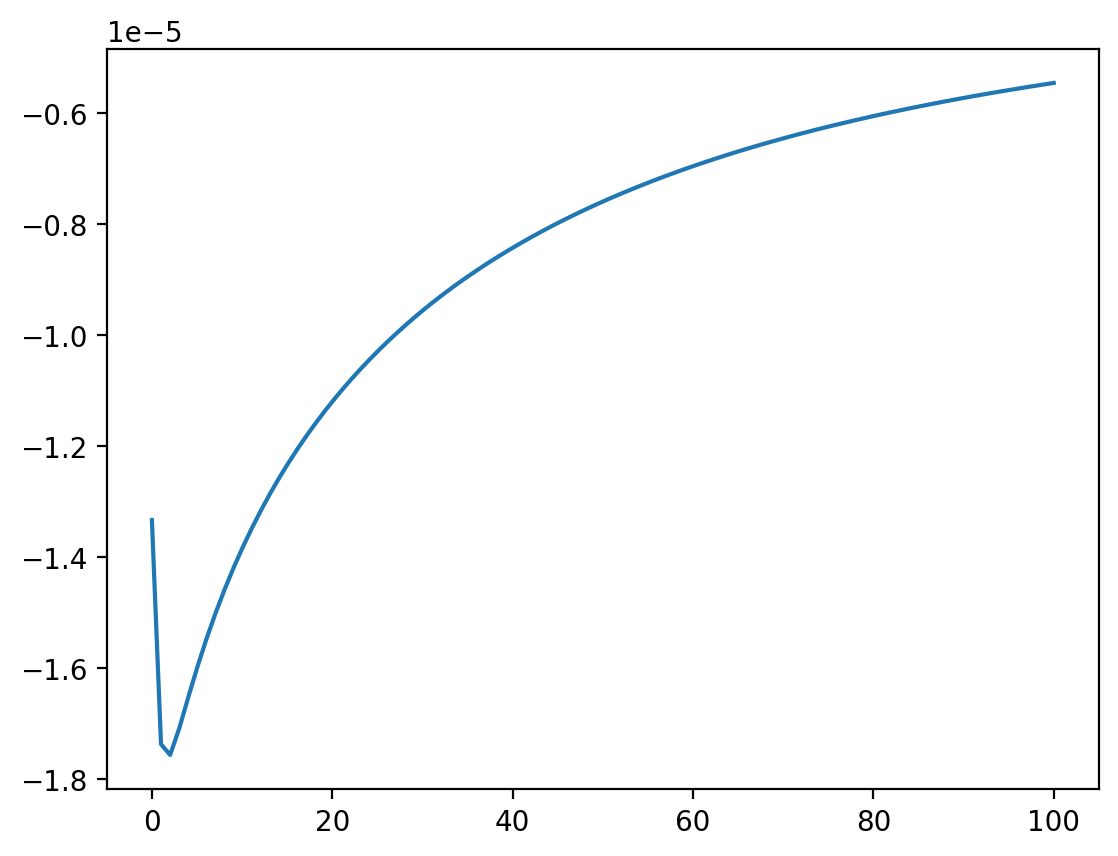

In [11]:
# z range too large causes divergent
z_arr=np.linspace(0,100,num=100) # z in [10^a,10^b]
eta_camb=np.zeros(len(z_arr))
eta_new=np.zeros(len(z_arr))

T1 = time.time()
for i in range(len(z_arr)):
    eta_camb[i]=results.conformal_time(z_arr[i])
    eta_new[i]=eta_fun(z_arr[i])
T2 = time.time()
print(f"{T2-T1}"+"seconds")
plt.plot(z_arr,(eta_camb-eta_new)/eta_camb)

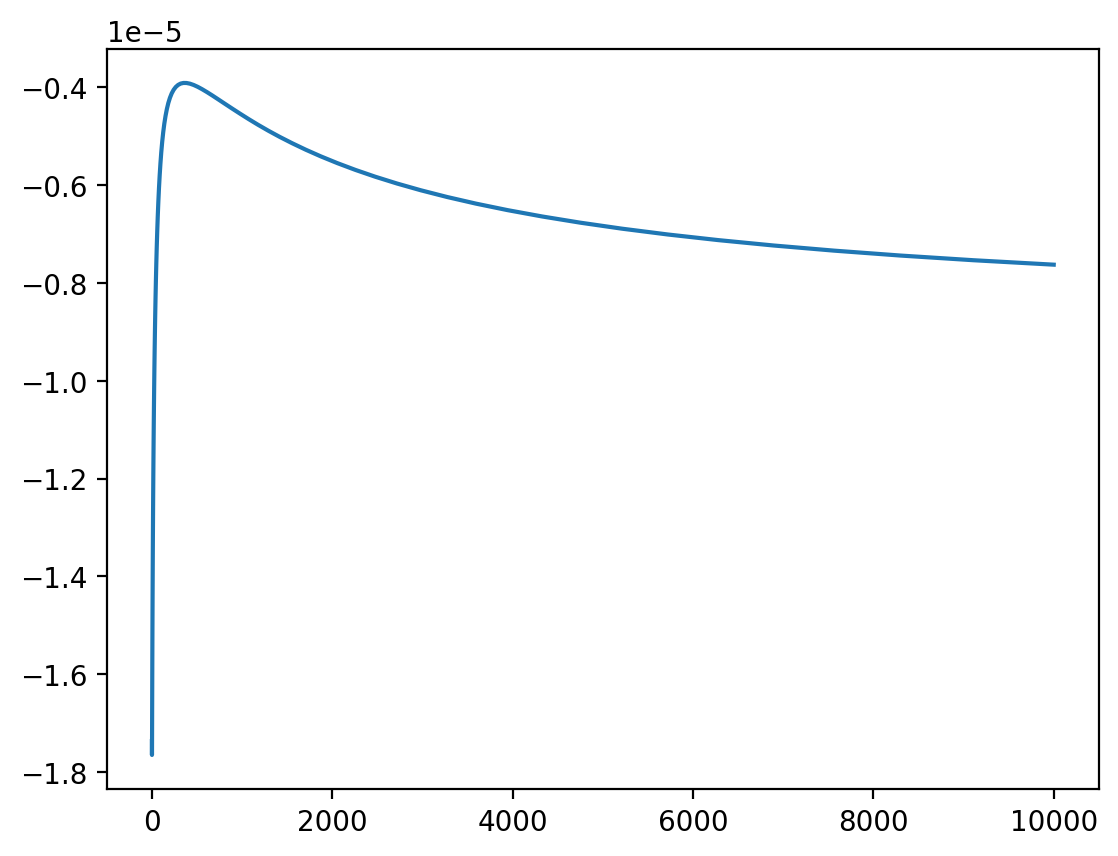

In [12]:
# z range too large causes slow converge
z_arr=np.logspace(0,4,num=100) # z in [10^a,10^b]
eta_camb=np.zeros(len(z_arr))
eta_new=np.zeros(len(z_arr))

for i in range(len(z_arr)):
    eta_camb[i]=results.conformal_time(z_arr[i])
    eta_new[i]=eta_fun(z_arr[i])
    
plt.plot(z_arr,(eta_camb-eta_new)/eta_camb)

In [11]:
tau = 0
h = 100
for z in np.linspace(200,1e6,int((1e6-200)/h)):
    k1 = h*1/Hz(z)
    k2 = h*1/Hz(z+h/2)
    k3 = h*1/Hz(z+h)
    tau = tau + (k1+k2*4+k3)/6

tau

0.0029347776104475835